In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from pathlib import Path

In [2]:
import cartopy
cartopy.config['data_dir'] = '/g/data/xp65/public/apps/cartopy-data'
cartopy.config['pre_existing_data_dir'] = '/g/data/xp65/public/apps/cartopy-data'
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [30]:
# --- Config ---
base = "/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics"
dataset = "NARCLIM"           # ['BARPA', 'CMIP6', 'CORDEX_CSIRO', 'CORDEX_Qld', 'NARCLIM']
experiment = "ssp126"   # ['historical', 'ssp126', 'ssp370', 'ssp585']
variable = "pr"             # ['mrro', 'mrso', 'pr']
drought_threshold = 'Perc_15'
baseline = 'Baseline_1970_2005'
scale = "Scale_3"           # ['Scale_3', 'Scale_12']

# --- Build path ---
path = Path(base) / dataset / experiment / variable / drought_threshold / baseline / scale

# --- Load all models ---
datasets = {}
for gcm_dir in sorted(path.iterdir()):
    if not gcm_dir.is_dir():
        continue
    nc_files = list(gcm_dir.rglob("*.nc"))
    if not nc_files:
        print(f"Warning: no .nc file found in {gcm_dir.name}")
        continue
    # Group files by their immediate parent folder structure
    # Works for both flat (GCM/*.nc) and nested (GCM/ensemble/RCM/*.nc)
    from itertools import groupby
    file_groups = {}
    for f in nc_files:
        # Build key from all subdirs between gcm_dir and the file
        relative_parts = f.relative_to(gcm_dir).parts[:-1]  # exclude filename
        if relative_parts:
            # Nested: e.g. ACCESS-CM2_r2i1p1f1_CCAMoc-v2112
            key = gcm_dir.name + "_" + "_".join(relative_parts)
        else:
            # Flat: e.g. ACCESS-CM2
            key = gcm_dir.name
        file_groups.setdefault(key, []).append(f)

    for key, files in file_groups.items():
        datasets[key] = xr.open_mfdataset(sorted(files), combine="by_coords")
        print(f"Loaded: {key}")


Loaded: ACCESS-ESM1-5_r6i1p1f1_NARCliM2-0-WRF412R3
Loaded: ACCESS-ESM1-5_r6i1p1f1_NARCliM2-0-WRF412R5
Loaded: EC-Earth3-Veg_r1i1p1f1_NARCliM2-0-WRF412R3
Loaded: EC-Earth3-Veg_r1i1p1f1_NARCliM2-0-WRF412R5
Loaded: MPI-ESM1-2-HR_r1i1p1f1_NARCliM2-0-WRF412R3
Loaded: MPI-ESM1-2-HR_r1i1p1f1_NARCliM2-0-WRF412R5
Loaded: NorESM2-MM_r1i1p1f1_NARCliM2-0-WRF412R3
Loaded: NorESM2-MM_r1i1p1f1_NARCliM2-0-WRF412R5
Loaded: UKESM1-0-LL_r1i1p1f2_NARCliM2-0-WRF412R3
Loaded: UKESM1-0-LL_r1i1p1f2_NARCliM2-0-WRF412R5


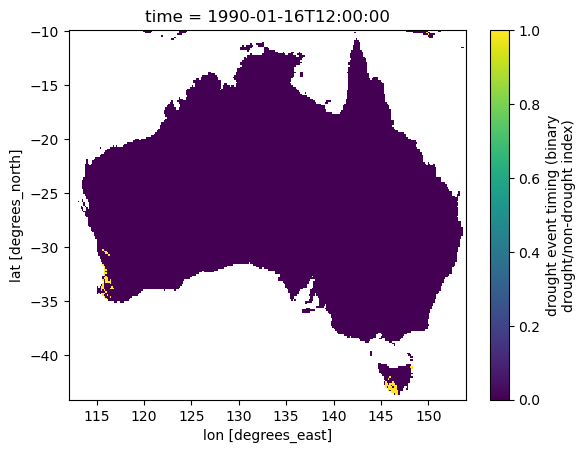

In [20]:
datasets["ACCESS-CM2_r4i1p1f1"].sel(time="1990-01").timing.plot()

In [16]:
datasets["ACCESS-CM2_r4i1p1f1"].lat

<xarray.DataArray 'lat' (lat: 221)> Size: 2kB
array([-43.9965, -43.842 , -43.6875, ..., -10.3155, -10.161 , -10.0065],
      shape=(221,))
Coordinates:
  * lat      (lat) float64 2kB -44.0 -43.84 -43.69 ... -10.32 -10.16 -10.01
Attributes:
    units:    degrees_north

In [26]:
datasets["ACCESS-CM2_r4i1p1f1"].sel(lat=-25, method="nearest").sel(lon=130, method="nearest").duration

<xarray.DataArray 'duration' (time: 660)> Size: 5kB
dask.array<getitem, shape=(660,), dtype=float64, chunksize=(660,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 5kB 1960-01-16T12:00:00 ... 2014-12-16T12:...
    lon      float64 8B 130.1
    lat      float64 8B -24.99
Attributes:
    long_name:  drought event duration (no. months)

In [103]:
# --- Config ---
base = "/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics"
dataset = "CORDEX_CSIRO"           # ['BARPA', 'CMIP6', 'CORDEX_CSIRO', 'CORDEX_Qld', 'NARCLIM']
experiment = "ssp126"   # ['historical', 'ssp126', 'ssp370', 'ssp585']
variable = "pr"             # ['mrro', 'mrso', 'pr']
drought_threshold = 'Perc_15'
baseline = 'Baseline_1970_2005'
scale = "Scale_3"           # ['Scale_3', 'Scale_12']

# --- Build path ---
path = Path(base) / dataset / experiment / variable / drought_threshold / baseline / scale

# --- Load all models ---
datasets_future = {}
for gcm_dir in sorted(path.iterdir()):
    if not gcm_dir.is_dir():
        continue
    nc_files = list(gcm_dir.rglob("*.nc"))
    if not nc_files:
        print(f"Warning: no .nc file found in {gcm_dir.name}")
        continue
    # Group files by their immediate parent folder structure
    # Works for both flat (GCM/*.nc) and nested (GCM/ensemble/RCM/*.nc)
    from itertools import groupby
    file_groups = {}
    for f in nc_files:
        # Build key from all subdirs between gcm_dir and the file
        relative_parts = f.relative_to(gcm_dir).parts[:-1]  # exclude filename
        if relative_parts:
            # Nested: e.g. ACCESS-CM2_r2i1p1f1_CCAMoc-v2112
            key = gcm_dir.name + "_" + "_".join(relative_parts)
        else:
            # Flat: e.g. ACCESS-CM2
            key = gcm_dir.name
        file_groups.setdefault(key, []).append(f)

    for key, files in file_groups.items():
        datasets_future[key] = xr.open_mfdataset(sorted(files), combine="by_coords")
        print(f"Loaded: {key}")


Loaded: ACCESS-CM2_r4i1p1f1
Loaded: ACCESS-ESM1-5_r6i1p1f1
Loaded: CESM2_r11i1p1f1
Loaded: CMCC-ESM2_r1i1p1f1
Loaded: CNRM-ESM2-1_r1i1p1f2
Loaded: EC-Earth3_r1i1p1f1
Loaded: NorESM2-MM_r1i1p1f1


In [104]:
if experiment == "historical":
    time_min = "1960"; time_max = "2014"
else:
    time_min = "2015"; time_max = "2100"

In [105]:
for name, ds in datasets.items():
    cal = ds.time.encoding.get("calendar", ds.time.dt.calendar)
    if cal != "proleptic_gregorian":
        print(name)
        datasets[name] = ds.sel(time=slice("1960", "2014")).convert_calendar("standard", align_on = "year")
    else:
        datasets[name] = ds.sel(time=slice("1960", "2014"))

CESM2_r11i1p1f1
CMCC-ESM2_r1i1p1f1
EC-Earth3_r1i1p1f1
NorESM2-MM_r1i1p1f1


In [106]:
for name, ds in datasets_future.items():
    cal = ds.time.encoding.get("calendar", ds.time.dt.calendar)
    if cal != "proleptic_gregorian":
        print(name)
        datasets_future[name] = ds.sel(time=slice(time_min, time_max)).convert_calendar("standard", align_on = "year")
    else:
        datasets_future[name] = ds.sel(time=slice(time_min, time_max))

CESM2_r11i1p1f1
CMCC-ESM2_r1i1p1f1
EC-Earth3_r1i1p1f1
NorESM2-MM_r1i1p1f1


In [107]:
# Determine the time under drought, i.e. the proportion of time that is under drought for each of the driving models
time_under_drought = {}
for name, ds in datasets.items():
    time_under_drought[name] = ds.timing.sum(dim="time", min_count=1) / len(ds.timing.time)

In [108]:
# Determine the time under drought, i.e. the proportion of time that is under drought for each of the driving models
time_under_drought_future = {}
for name, ds in datasets_future.items():
    time_under_drought_future[name] = ds.timing.sum(dim="time", min_count=1) / len(ds.timing.time)

In [109]:
time_under_drought_all = xr.concat(list(time_under_drought.values()),dim="forcing_gcm",  join="override",   # Forcibly uses the lat/lon of the very first dataset
    coords="minimal"   # Prevents copying duplicate lat/lon coordinates per GCM
    ).assign_coords(forcing_gcm=list(time_under_drought.keys()))

In [110]:
time_under_drought_all_future = xr.concat(list(time_under_drought_future.values()),dim="forcing_gcm",  join="override",   # Forcibly uses the lat/lon of the very first dataset
    coords="minimal"   # Prevents copying duplicate lat/lon coordinates per GCM
    ).assign_coords(forcing_gcm=list(time_under_drought_future.keys()))

In [111]:
time_under_drought_all_mmm = time_under_drought_all.mean(dim="forcing_gcm")
time_under_drought_all_mmm_future = time_under_drought_all_future.mean(dim="forcing_gcm")


In [112]:
time_under_drought_all_diff = time_under_drought_all_mmm_future - time_under_drought_all_mmm

In [113]:
time_under_drought_all_diff

<xarray.DataArray 'timing' (lat: 341, lon: 421)> Size: 1MB
dask.array<sub, shape=(341, 421), dtype=float64, chunksize=(16, 21), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 3kB -44.0 -43.9 -43.8 -43.7 ... -10.2 -10.1 -10.0
  * lon      (lon) float64 3kB 112.0 112.1 112.2 112.3 ... 153.8 153.9 154.0
Attributes:
    long_name:  drought event timing (binary drought/non-drought index)

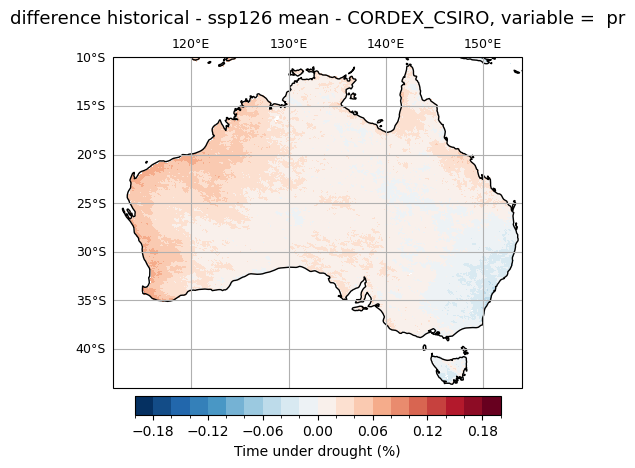

In [114]:
ax = plt.subplot(projection=ccrs.PlateCarree())
time_under_drought_all_diff.plot.pcolormesh(x="lon", y="lat", ax=ax, cmap="RdBu_r", levels=np.linspace(-0.2, 0.2, 21),
                                           cbar_kwargs={
                                               "label": "Time under drought (%)",
                                               "shrink":0.6,
                                               "pad": 0.02,
                                               "location":"bottom", 
                                           }, add_colorbar=True)
ax.coastlines()
gl = ax.gridlines(draw_labels=True)
gl.bottom_labels = False
gl.right_labels = False
ax.set_title(f"difference historical - {experiment} mean - {dataset}, variable =  {variable}", fontsize=13, pad=10)

gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

plt.tight_layout()

plt.savefig(f"/g/data/dt6/cb6525/graphs/time_under_drought/difference_historical-{experiment}_{dataset}_time_under_drought_{variable}.png", dpi=300, bbox_inches="tight")